# BBox and Object Detection with Mistral

Vision-capable models are a core part of modern systems for image classification and image understanding. With Mistral Large 4 (ML4), we have **significantly improved vision and object detection capabilities**, allowing developers to leverage the model for BBox extraction, or even to point at objects and screen components.


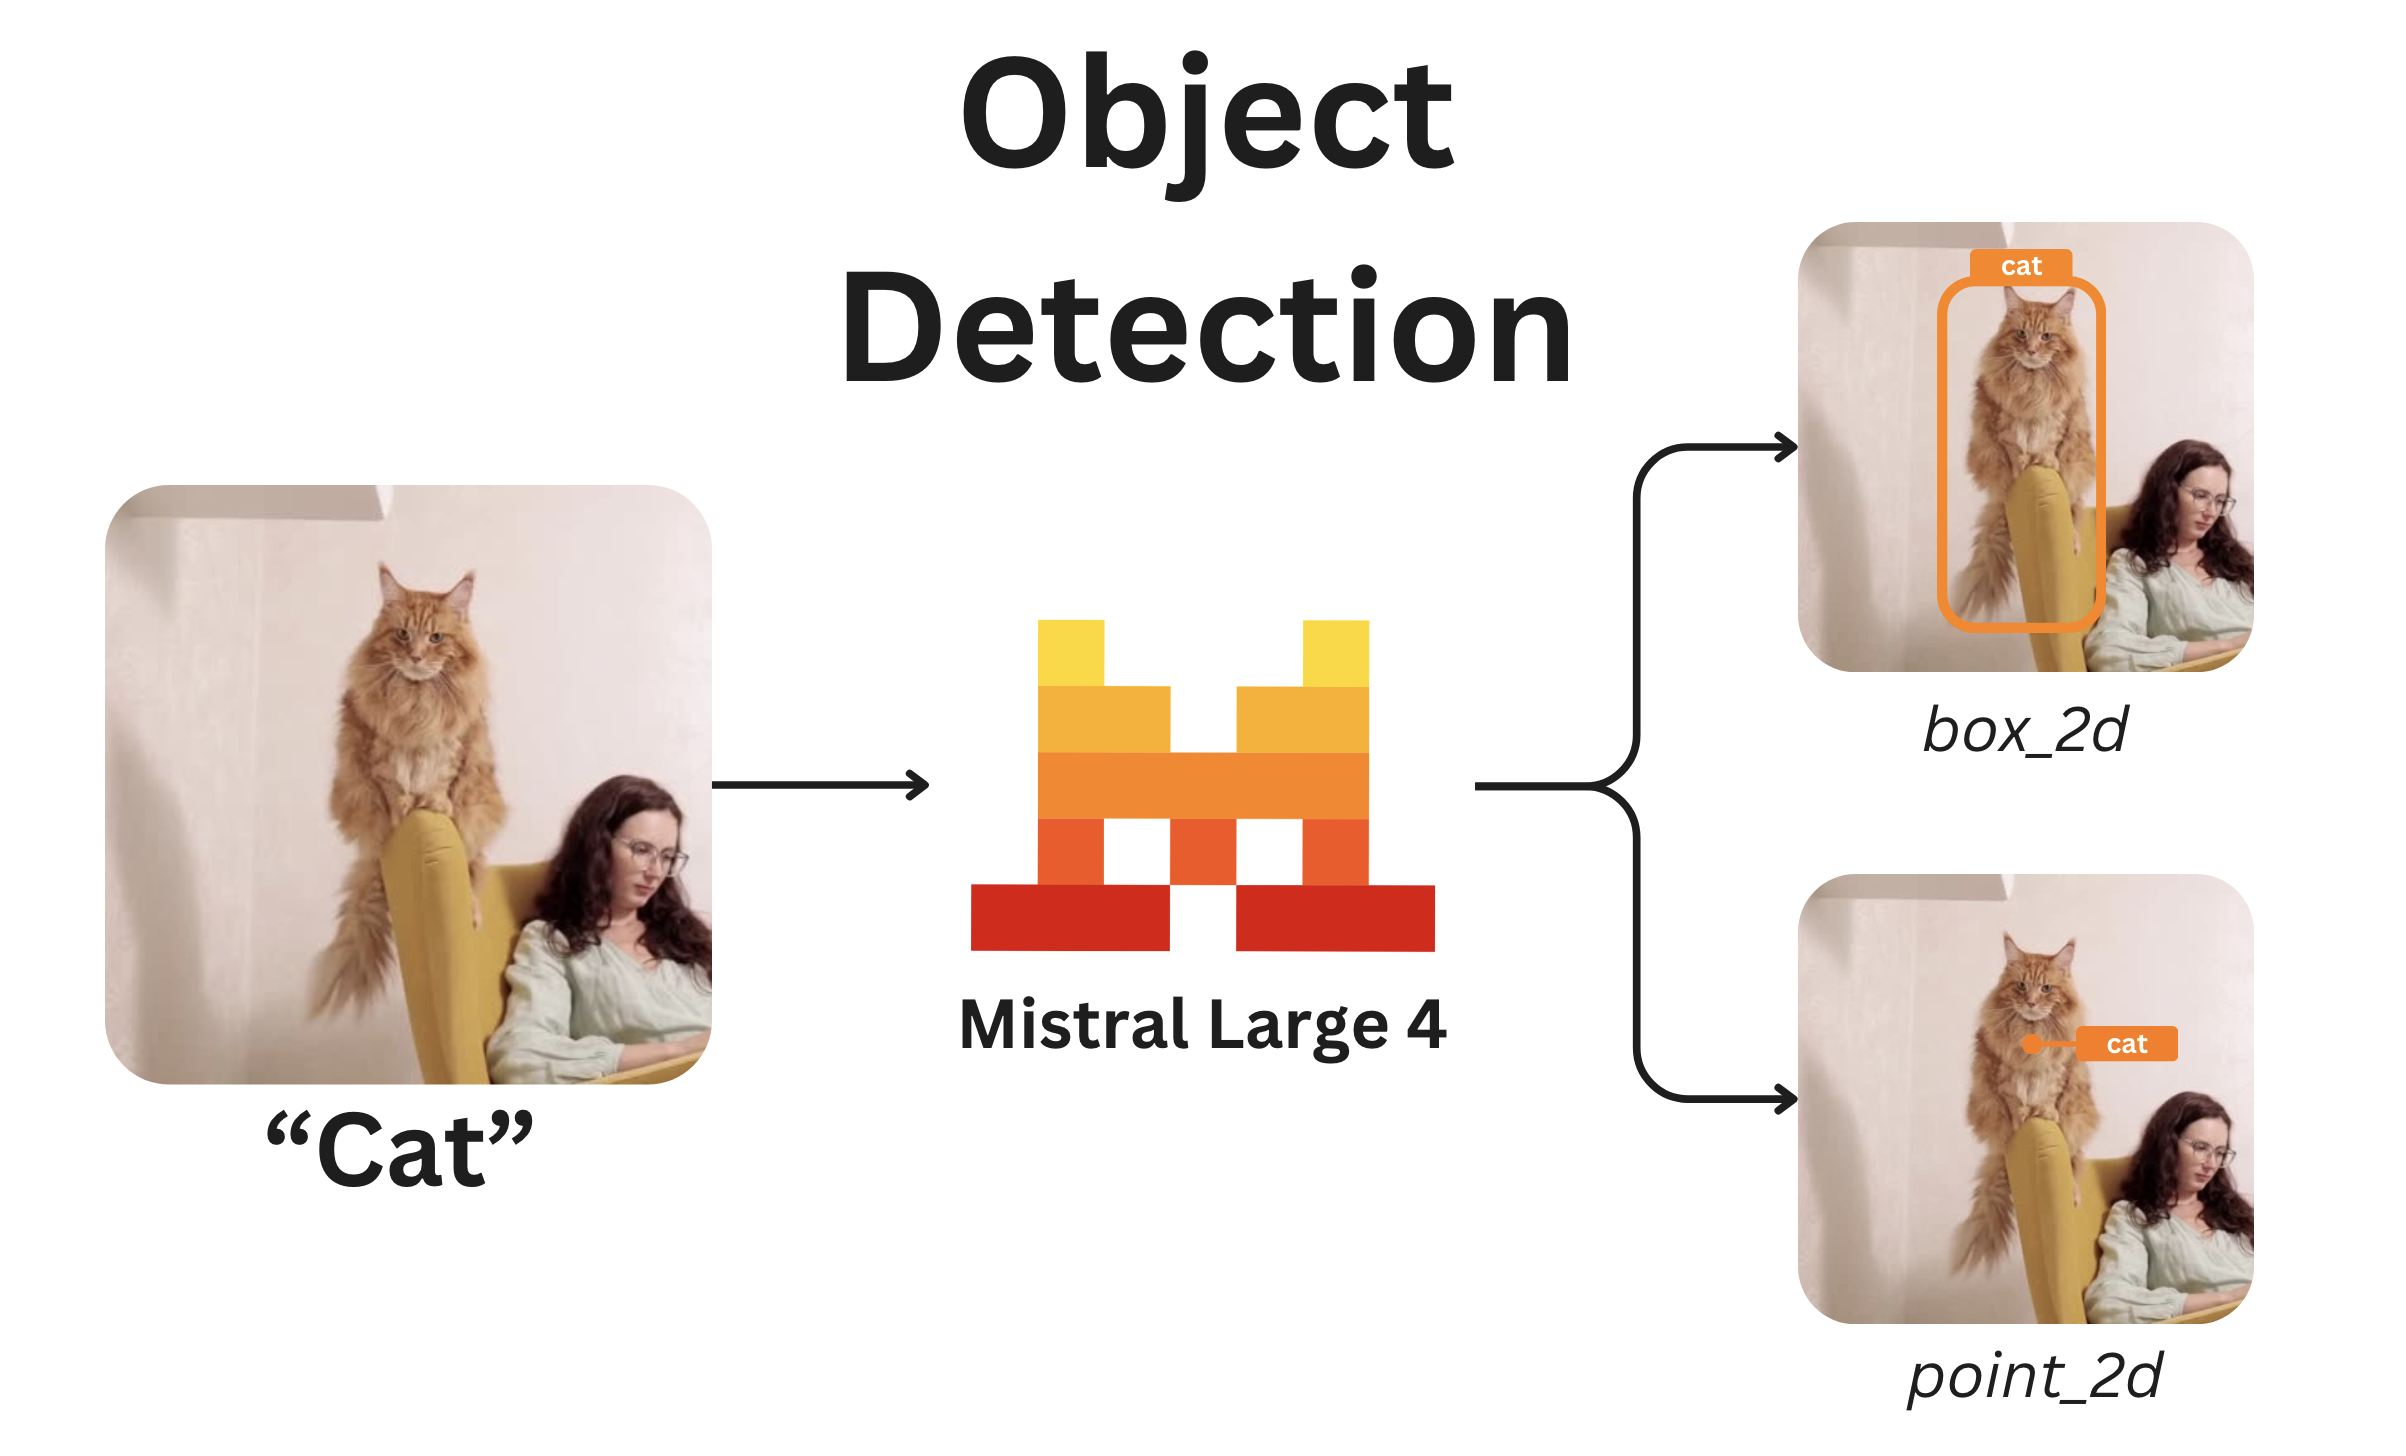

In this cookbook, we will explore how you can use ML4 for object detection.

## Install
First, we install the `mistralai` SDK and set up an API key created in our [Studio](https://console.mistral.ai/api-keys).

In [ ]:
!pip install mistralai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.7 MB/s eta 0:00:00


In [ ]:
from mistralai.client import Mistral
import getpass
import os

if not os.environ.get("MISTRAL_API_KEY"):
    os.environ["MISTRAL_API_KEY"] = getpass.getpass("Mistral API key: ")

client = Mistral(os.environ["MISTRAL_API_KEY"])

Mistral API key: ··········


## Calling a Model
With our client ready, we can call the model on the image we want to analyze. Let's give it a try and request bounding boxes around a photo of the Eiffel Tower.

In [ ]:
image_url = "https://docs.mistral.ai/img/eiffel-tower-paris.jpg"

model = "mistral-large-4"

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "I want you to generate two bounding boxes: one around the spire of the Eiffel Tower, and one around the arch."
            },
            {
                "type": "image_url",
                "image_url": image_url
            }
        ]
    }
]

chat_response = client.chat.complete(
    model=model,
    messages=messages,
    temperature=0
)

In [ ]:
text_content = chat_response.choices[0].message.content
print(text_content)

Here are the bounding boxes: {"box_2d": [500, 70, 517, 108], "label": "spire"}{"box_2d": [248, 828, 713, 999], "label": "arch"}


## Output Format

The model replied with dictionaries; these correspond to the bounding boxes. We strongly recommend the following format for object detection:
- BBox: `{"box_2d": [xmin, ymin, xmax, ymax], "label": string}`
- Point: `{"point_2d": [x, y], "label": string}`

With x and y coordinates normalized between 0 and 1000 [0-999].

Let's extract the dictionaries with our coordinates and display the results.

In [ ]:
import re
import json

pattern = re.compile(r'\{(?=[^{}]*\b(?:box_2d|point_2d)\b)(?=[^{}]*\blabel\b)[^{}]*\}')
results = [json.loads(t) for t in pattern.findall(text_content)]
print(results)

[{'box_2d': [500, 70, 517, 108], 'label': 'spire'}, {'box_2d': [248, 828, 713, 999], 'label': 'arch'}]


In [ ]:
# @title Display Results

import urllib.request

from PIL import Image, ImageColor, ImageDraw, ImageFont
from IPython.display import display

def show_results(image_url, results, show_labels = True):

    width = 512
    font_size = 24

    with urllib.request.urlopen(image_url) as resp:
        image = Image.open(resp).convert("RGB")

    if image.width > width:
        image = image.resize((width, image.height * width // image.width), Image.LANCZOS)

    draw = ImageDraw.Draw(image)
    w, h = image.size
    sx, sy = w / 1000, h / 1000  # coordinates are normalized 0-999

    palette = ["lime", "red", "deepskyblue", "orange", "magenta", "yellow", "violet", "cyan"]
    label_colors = {}

    font = ImageFont.load_default(size=font_size)

    pad = 8

    def label_chip(text, xy, color):
        """Draw text on a colored chip; xy = chip's top-left corner."""
        x, y = xy
        tb = draw.textbbox((0, 0), text, font=font)
        cw, ch = tb[2] - tb[0] + 2 * pad, tb[3] - tb[1] + 2 * pad
        x = max(0, min(x, w - cw))
        draw.rectangle([x, y, x + cw, y + ch], fill=color)
        ink = "black" if sum(ImageColor.getrgb(color)) > 400 else "white"
        draw.text((x + pad - tb[0], y + pad - tb[1]), text, fill=ink, font=font)

    for res in results:
        label = str(res.get("label", ""))
        color = label_colors.setdefault(label, palette[len(label_colors) % len(palette)])

        if "box_2d" in res:  # [xmin, ymin, xmax, ymax] in 0-999
            x0, y0, x1, y1 = [int(v * s) for v, s in zip(res["box_2d"], (sx, sy, sx, sy))]
            draw.rectangle([x0, y0, x1, y1], outline=color, width=3)
            ch = draw.textbbox((0, 0), label, font=font)[3] + 2 * pad
            if show_labels:
                label_chip(label, (x0, y0 - ch - 2 if y0 - ch - 2 >= 0 else y0 + 2), color)

        elif "point_2d" in res:  # [x, y] in 0-999
            x, y = int(res["point_2d"][0] * sx), int(res["point_2d"][1] * sy)
            draw.ellipse([x - 3, y - 3, x + 3, y + 3], fill=color)
            ch = draw.textbbox((0, 0), label, font=font)[3] + 2 * pad
            if show_labels:
                label_chip(label, (x + 9, y - ch // 2), color)

    display(image)

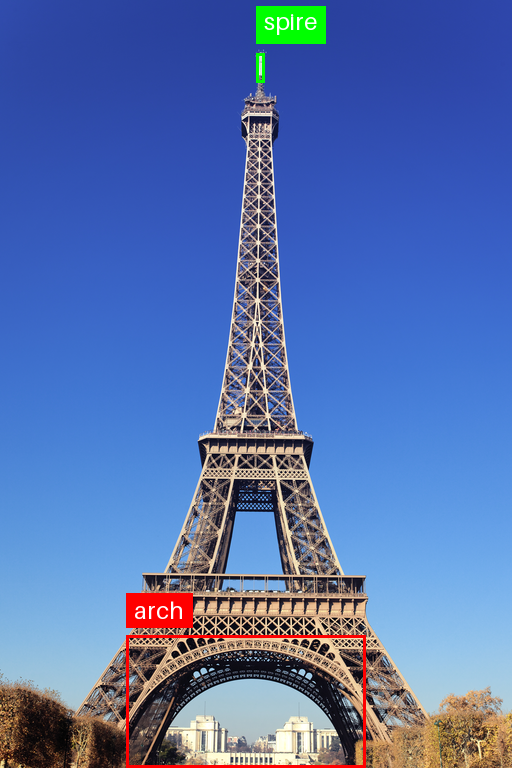

In [ ]:
show_results(image_url, results)

Perfect - we have the coordinates of the requested objects.

## Recommended Usage
For reliability and good performance, we recommend using these object detection capabilities with the following tips:
- **Include a system prompt detailing the task**:
  - A quick summary of the model/agent objective.
  - The object detection tasks, i.e. `box_2d` and `point_2d`.
  - A response format giving an example of the expected output.
- **Expected output**: ML4 provides the best results when providing the data as dictionaries, as follows:
  - Bounding Boxes: `{'box_2d': [xmin, ymin, xmax, ymax], 'label': string}`
  - Points: `{'point_2d': [x, y], 'label': string}`
  - With all coordinates normalized between 0 and 999.
- **Free generation**: we recommend not using structured outputs, and instead letting the model reply freely following the instructions.
- **Results extraction**: once the model has answered, extract the results by parsing the dictionaries. We recommend a regex such as: `r'\{(?=[^{}]*\b(?:box_2d|point_2d)\b)(?=[^{}]*\blabel\b)[^{}]*\}'`
- **One type only**: ML4 currently performs best when handling `box_2d` or `point_2d` separately - request one or the other, but not both simultaneously, for the best performance.

### System prompt & Results Extraction
Let's define a system prompt we can use for object detection based on the tips above; a model objective, tasks explained, and the response format.

We will also create a simple results-extraction function using regex.

In [ ]:
SYSTEM = """You are an object detection vision model tasked with identifying objects in an image. Given a label and a type of identification, output the list of objects or entities requested.
If the object or entity is not present, reply with None.

# Types of Tasks
- box_2d: Detect bounding boxes corresponding to the objects requested, with 4 coordinates: [xmin, ymin, xmax, ymax]
- point_2d: Detect and point to the corresponding object, with 2 coordinates: [x, y]

# Response Format
Reply only with a list of dictionaries in the following standardized format:
{<type_2d>: [...], "label": <string>}
{<type_2d>: [...], "label": <string>}
...
All coordinates must be normalized between 0 and 1000.

## Response Examples
### Bounding Boxes
{"box_2d": [200, 400, 500, 600], "label": "bird"}
{"box_2d": [400, 900, 900, 600], "label": "person"}
### Points
{"point_2d": [200, 400], "label": "bird"}
{"point_2d": [400, 900], "label": "person"}
"""

In [ ]:
import re
import json

def extract_results(text_content: str) -> list:
    pattern = re.compile(r'\{(?=[^{}]*\b(?:box_2d|point_2d)\b)(?=[^{}]*\blabel\b)[^{}]*\}')
    results = [json.loads(t) for t in pattern.findall(text_content)]
    return results

### Box 2D & Point 2D
With everything ready, let's test our model on both tasks: box_2d and point_2d.

In [ ]:
box_messages = [
    {
        "role": "system",
        "content": SYSTEM
    },
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Generate two bounding boxes to find the spire and the arch of the Eiffel Tower."
            },
            {
                "type": "image_url",
                "image_url": image_url
            }
        ]
    }
]

In [ ]:
chat_response = client.chat.complete(
    model=model,
    messages=box_messages,
    temperature=0
)
text_content = chat_response.choices[0].message.content
print(text_content)

{"box_2d": [500, 68, 519, 105], "label": "spire"}{"box_2d": [245, 828, 723, 998], "label": "arch"}


In [ ]:
results = extract_results(text_content)
print(results)

[{'box_2d': [500, 68, 519, 105], 'label': 'spire'}, {'box_2d': [245, 828, 723, 998], 'label': 'arch'}]


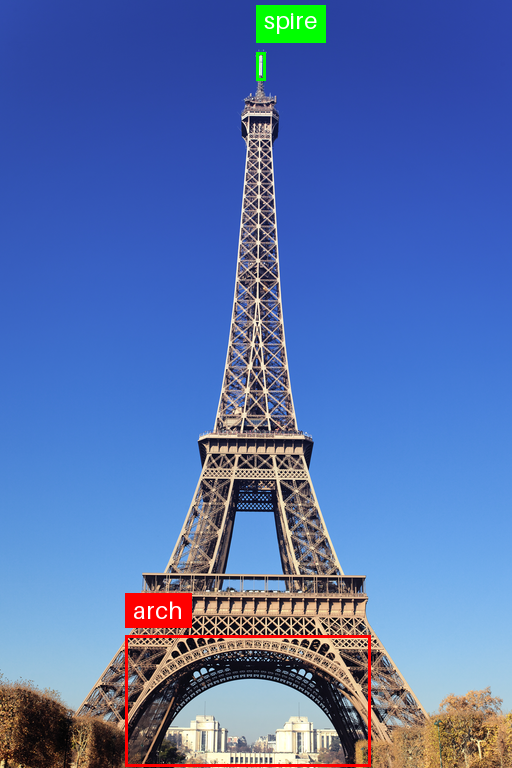

In [ ]:
show_results(image_url, results)

In [ ]:
point_messages = [
    {
        "role": "system",
        "content": SYSTEM
    },
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Generate two points to find the spire and the arch of the Eiffel Tower."
            },
            {
                "type": "image_url",
                "image_url": image_url
            }
        ]
    }
]

In [ ]:
chat_response = client.chat.complete(
    model=model,
    messages=point_messages,
    temperature=0
)
text_content = chat_response.choices[0].message.content
print(text_content)

{"point_2d": [509, 104], "label": "spire"}{"point_2d": [484, 915], "label": "arch"}


In [ ]:
results = extract_results(text_content)
print(results)

[{'point_2d': [509, 104], 'label': 'spire'}, {'point_2d': [484, 915], 'label': 'arch'}]


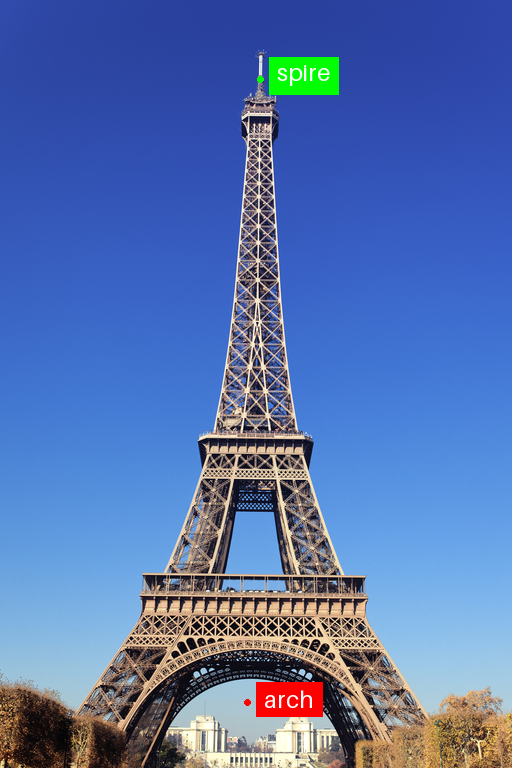

In [ ]:
show_results(image_url, results)

### Other Examples
The model can be leveraged for multiple use cases; below we show the model detecting individuals and web components.

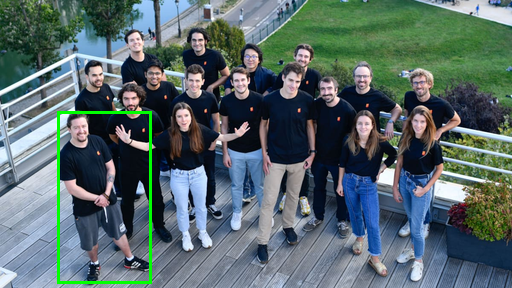

In [ ]:
# @title Detect People - "Find the individual with shorts."
image_url = "https://raw.githubusercontent.com/mistralai/cookbook/refs/heads/main/images/individuals.png"

individuals_messages = [
    {
        "role": "system",
        "content": SYSTEM
    },
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Generate a bounding boxe to find the individual with shorts in this image."
            },
            {
                "type": "image_url",
                "image_url": image_url
            }
        ]
    }
]
chat_response = client.chat.complete(
    model=model,
    messages=individuals_messages,
    temperature=0
)
text_content = chat_response.choices[0].message.content
results = extract_results(text_content)
show_results(image_url, results, show_labels=False)

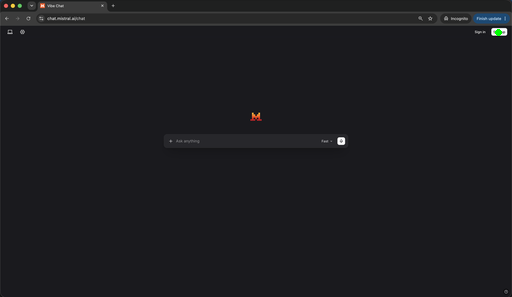

In [ ]:
# @title Detect Web Components - "Point to the sign-up button."
image_url = "https://raw.githubusercontent.com/mistralai/cookbook/refs/heads/main/images/webvibe_image.png"

web_messages = [
    {
        "role": "system",
        "content": SYSTEM
    },
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Point to the sign-up button."
            },
            {
                "type": "image_url",
                "image_url": image_url
            }
        ]
    }
]
chat_response = client.chat.complete(
    model=model,
    messages=web_messages,
    temperature=0
)
text_content = chat_response.choices[0].message.content
results = extract_results(text_content)
show_results(image_url, results, show_labels=False)